#**Algoritma Klasifikasi**

**STEP 1: Load & EDA Singkat**

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Membuat DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)

print("\nDistribusi Target")
print(pd.Series(y).value_counts())

print("\nNama Target")
print(data.target_names)

Shape: (569, 30)

Distribusi Target
1    357
0    212
Name: count, dtype: int64

Nama Target
['malignant' 'benign']


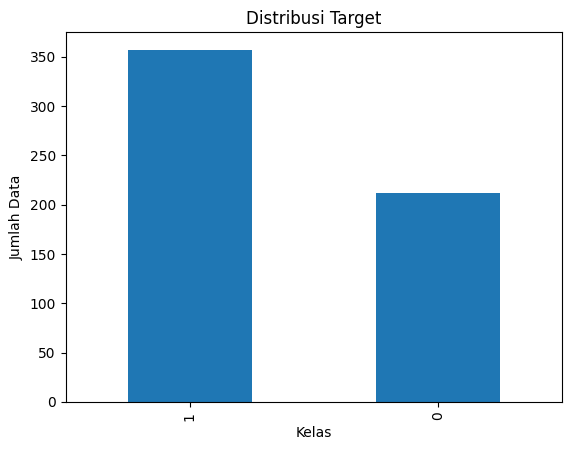

In [2]:
import matplotlib.pyplot as plt

pd.Series(y).value_counts().plot(kind='bar')

plt.title("Distribusi Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.show()

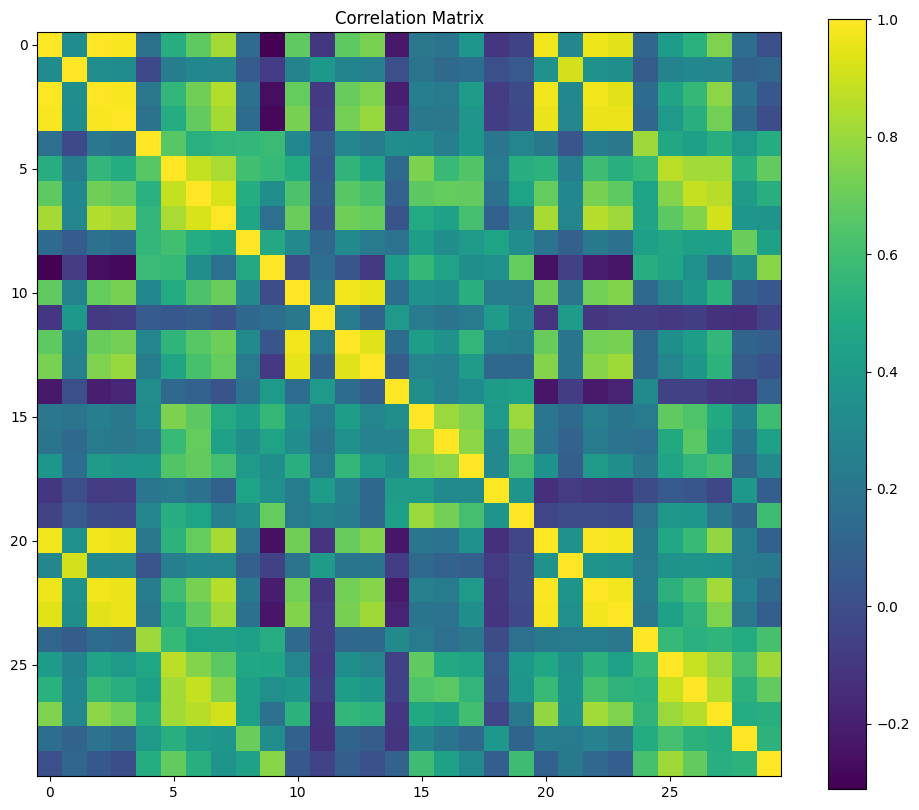

In [3]:
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)

plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

**STEP 2: Preprocessing**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membagi data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran Data Training :", X_train.shape)
print("Ukuran Data Testing  :", X_test.shape)

print()

print("Distribusi Training")
print(pd.Series(y_train).value_counts())

print()

print("Distribusi Testing")
print(pd.Series(y_test).value_counts())

Ukuran Data Training : (455, 30)
Ukuran Data Testing  : (114, 30)

Distribusi Training
1    285
0    170
Name: count, dtype: int64

Distribusi Testing
1    72
0    42
Name: count, dtype: int64


In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

print(X_train_s[:5])

print()

print("Sebelum Scaling")
print(X_train.head())

print()

print("Sesudah Scaling")
print(pd.DataFrame(X_train_s, columns=X.columns).head())

[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1.73738602e-01]
 [-9.7

**STEP 3: Latih Logistic Regression**

In [7]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
 'Koefisien': log_model.coef_[0]
 }).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


**STEP 4: Latih Decision Tree**

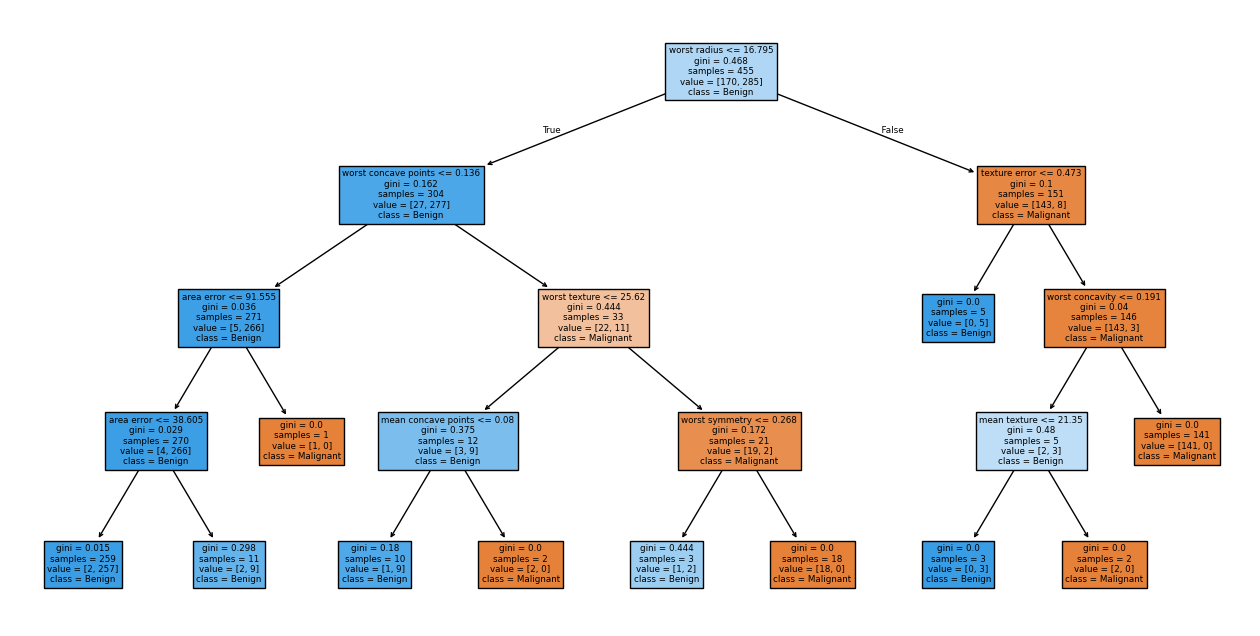

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4,
    random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
class_names=['Malignant','Benign'], filled=True)
plt.show()

**STEP 5: Evaluasi & Bandingkan**


=== Logistic Regression ===


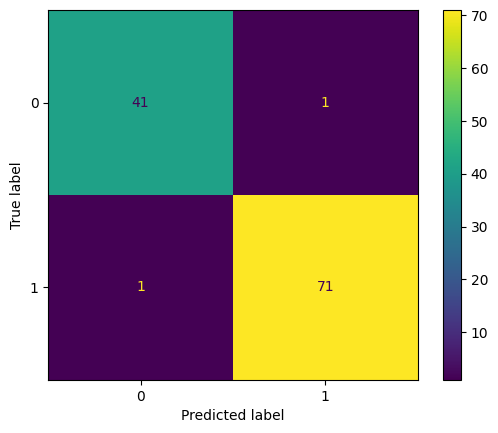

Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===


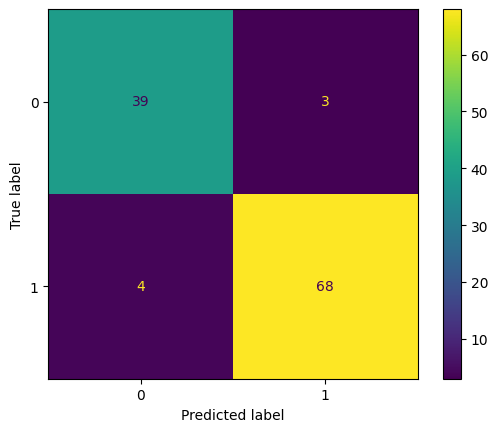

Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


In [9]:
from sklearn.metrics import (confusion_matrix,
accuracy_score, precision_score,
recall_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay

for name, y_pred in [('Logistic Regression', y_pred_log),
('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")

In [10]:
hasil = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_tree)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_tree)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_tree)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_tree)
    ]
})

hasil.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


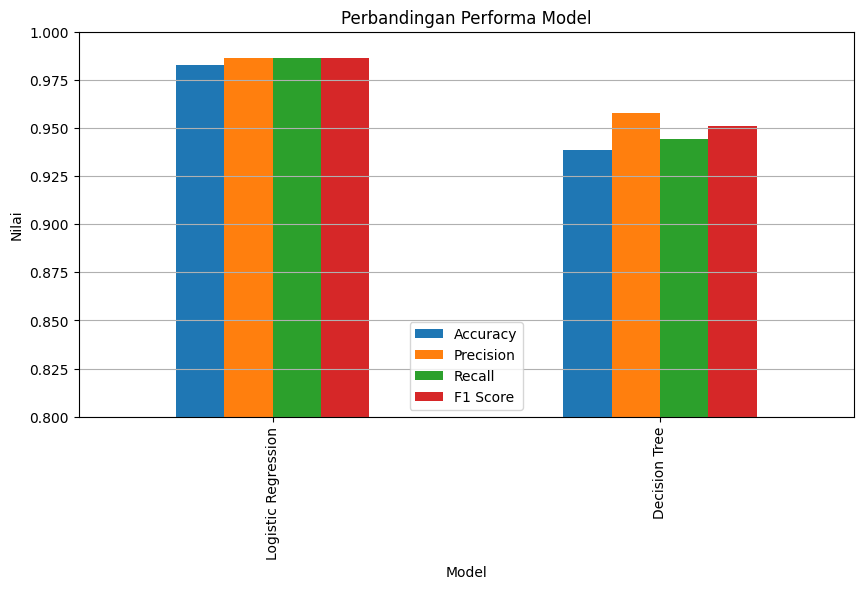

In [11]:
hasil.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Perbandingan Performa Model")

plt.ylabel("Nilai")

plt.ylim(0.8,1.0)

plt.grid(axis="y")

plt.show()

**Jawaban Pertanyaan Modul**:

1. Model mana yang memiliki Recall lebih tinggi?

    Berdasarkan hasil evaluasi, Logistic Regression memiliki nilai Recall yang lebih tinggi dibandingkan Decision Tree, sehingga lebih baik dalam mendeteksi pasien yang benar-benar menderita kanker.

2. Mengapa Recall paling penting?

    Recall menjadi metrik paling penting pada diagnosis kanker karena Recall mengukur kemampuan model mendeteksi seluruh kasus positif. Nilai Recall yang tinggi berarti jumlah False Negative menjadi kecil sehingga risiko pasien kanker yang tidak terdeteksi dapat diminimalkan.


3. Apakah terdapat perbedaan signifikan?

    Kedua model memiliki performa yang baik. Namun Logistic Regression memberikan nilai evaluasi yang sedikit lebih tinggi dibandingkan Decision Tree. Sementara itu, Decision Tree lebih mudah diinterpretasikan karena menghasilkan aturan keputusan berbentuk pohon.



**Kesimpulan**

Berdasarkan hasil evaluasi, kedua algoritma menunjukkan kemampuan klasifikasi yang sangat baik jika dilihat dari nilai Accuracy, Precision, Recall, dan F1-Score. Meskipun demikian, Logistic Regression secara keseluruhan memperoleh performa yang sedikit lebih unggul dibandingkan Decision Tree pada dataset yang digunakan. Sementara itu, Decision Tree memiliki kelebihan dari sisi interpretasi karena mampu menghasilkan aturan keputusan yang dapat divisualisasikan dalam bentuk pohon, sehingga proses pengambilan keputusan lebih mudah dipahami, termasuk oleh pengguna yang tidak memiliki latar belakang teknis.

Pada studi kasus diagnosis kanker, Recall merupakan metrik yang paling krusial karena mencerminkan kemampuan model dalam mengidentifikasi seluruh pasien yang benar-benar mengidap kanker. Semakin tinggi nilai Recall, semakin kecil kemungkinan terjadinya False Negative, yaitu kondisi ketika pasien yang sebenarnya menderita kanker justru diprediksi sehat. Kesalahan seperti ini dapat menimbulkan konsekuensi serius terhadap penanganan dan pengobatan pasien.

Dari praktikum yang telah dilakukan, dapat disimpulkan bahwa pemilihan algoritma klasifikasi tidak seharusnya hanya berfokus pada nilai akurasi. Karakteristik permasalahan serta tujuan analisis juga perlu menjadi pertimbangan utama dalam menentukan model yang paling sesuai. Selain itu, penggunaan metrik evaluasi yang tepat berperan penting dalam menilai kualitas model Machine Learning, sehingga hasil prediksi yang dihasilkan dapat lebih relevan dan bermanfaat untuk kebutuhan di dunia nyata, terutama dalam bidang kesehatan.